In [4]:
import pandas as pd

In [5]:
base_path = r'data/smartphone_addiction'
train_path = base_path + '/' + 'train.csv'
test_path = base_path + '/' + 'test.csv'

In [6]:
import os
os.path.exists('../../' + base_path)

True

In [7]:
os.listdir()

['initial.ipynb',
 'mlflow.db',
 'mlruns',
 'sample_submission.csv',
 'submission000.csv',
 'submission001.csv',
 'submission002.csv',
 'test.csv',
 'train.csv']

In [8]:
train_df = pd.read_csv('../../'+ train_path)

In [9]:
df = train_df.copy()

In [10]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [11]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [12]:
# Column names and types
TARGET = "addicted_label"
ID = "id"
num_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
]

cat_cols = [
    'gender',               # Male, Female, Other  
    'stress_level',         # High, Low, Medium
    'academic_work_impact'  # Yes, No
]

In [13]:
df[['gender', 'academic_work_impact']].value_counts()

gender  academic_work_impact
Male    Yes                     106532
Female  Yes                     105785
Other   Yes                     104603
Male    No                      103167
Female  No                      101749
Other   No                       98718
Name: count, dtype: int64

In [14]:
df[['gender', 'stress_level']].value_counts()

gender  stress_level
Other   High            72222
Male    High            69932
Female  High            69735
Male    Low             68191
        Medium          67935
Female  Low             67884
        Medium          66544
Other   Medium          64415
        Low             63274
Name: count, dtype: int64

In [15]:
df[['academic_work_impact', 'stress_level']].value_counts()

academic_work_impact  stress_level
Yes                   High            109871
No                    High             99490
Yes                   Low              99349
                      Medium           99100
No                    Low              97849
                      Medium           97767
Name: count, dtype: int64

In [16]:
df[['gender', 'academic_work_impact', 'stress_level']].value_counts()

gender  academic_work_impact  stress_level
Other   Yes                   High            36332
Female  Yes                   High            34562
Male    Yes                   High            34490
                              Medium          32535
                              Low             32411
Female  Yes                   Low             32390
Male    No                    Low             32344
Other   No                    High            32218
Male    No                    Medium          32041
Female  No                    Low             32024
Male    No                    High            31849
Female  Yes                   Medium          31671
        No                    High            31499
                              Medium          31431
Other   Yes                   Medium          30847
                              Low             30532
        No                    Medium          30238
                              Low             29589
Name: count, dtype: i

In [21]:
df[['gender', 'academic_work_impact', 'stress_level', TARGET]].value_counts()

gender  academic_work_impact  stress_level  addicted_label
Other   Yes                   High          1                 25405
Male    Yes                   High          1                 24992
Female  Yes                   High          1                 24302
Male    Yes                   Low           1                 23521
        No                    Low           1                 23417
        Yes                   Medium        1                 23348
        No                    High          1                 23166
                              Medium        1                 23078
Female  Yes                   Low           1                 22868
Other   No                    High          1                 22782
Female  No                    Low           1                 22660
                              High          1                 22318
        Yes                   Medium        1                 22131
        No                    Medium        1            

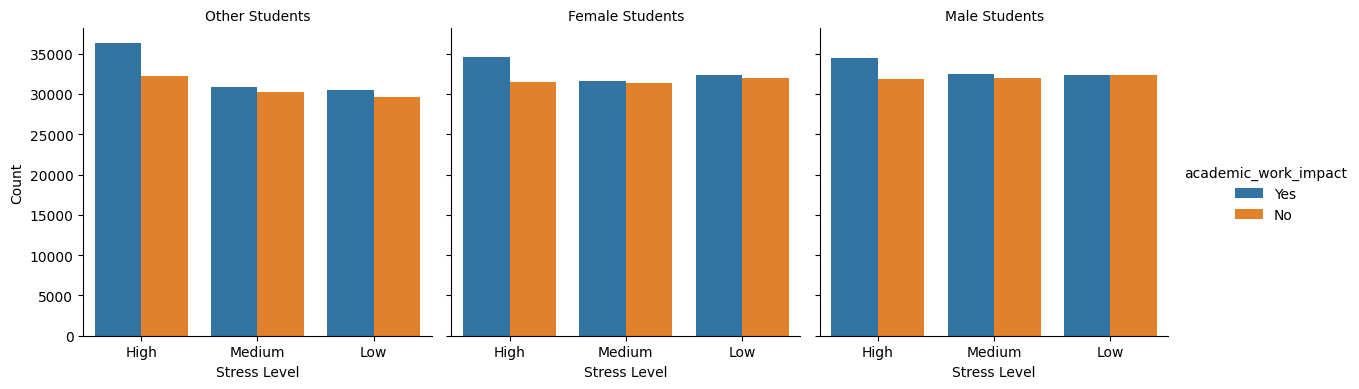

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to convert the MultiIndex Series from value_counts() into a DataFrame
df_counts = (
    df[["gender", "academic_work_impact", "stress_level"]]
    .value_counts()
    .reset_index(name="count")
)

# Create a faceted grid of bar plots
g = sns.catplot(
    data=df_counts,
    x="stress_level",
    y="count",
    hue="academic_work_impact",
    col="gender",
    kind="bar",
    height=4,
    aspect=1,
)

g.set_axis_labels("Stress Level", "Count")
g.set_titles("{col_name} Students")
plt.show()


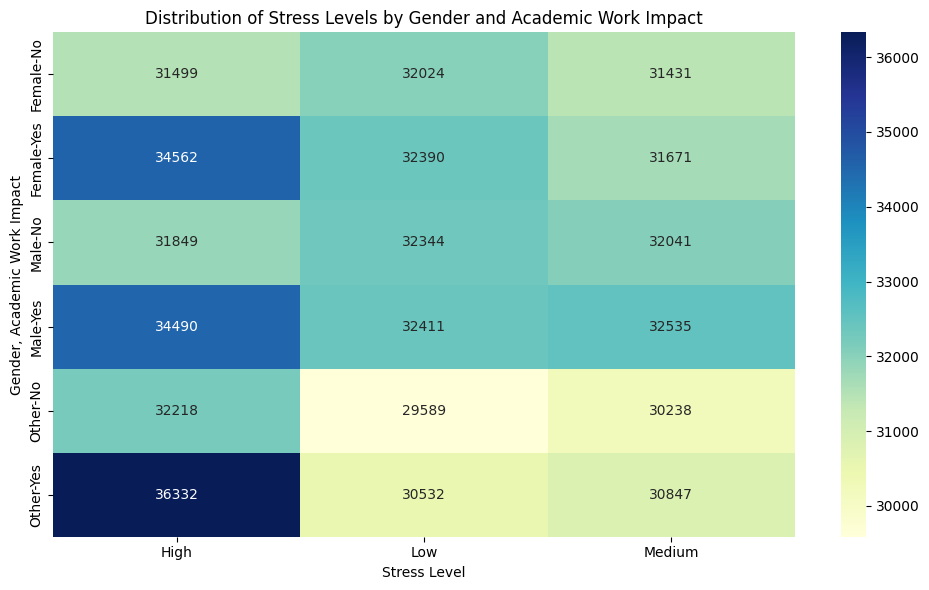

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data to create a matrix format
df_pivot = (
    df.groupby(["gender", "academic_work_impact", "stress_level"])
    .size()
    .unstack(fill_value=0)
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Distribution of Stress Levels by Gender and Academic Work Impact")
plt.ylabel("Gender, Academic Work Impact")
plt.xlabel("Stress Level")
plt.tight_layout()
plt.show()


In [17]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")

c:\Users\laksh\Documents\YashFiles\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
from __future__ import annotations

import inspect
import json
import logging
from copy import deepcopy
from typing import Any, Dict, List, Optional, Sequence

import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight


logger = logging.getLogger(__name__)


def train_binary_classifier_5fold(
    df: pd.DataFrame,
    feature_names: Sequence[str],
    target: str,
    description: str,
    model: Any,
    model_params: Optional[Dict[str, Any]] = None,
    experiment_name: str = "binary_classification",
    run_name: Optional[str] = None,
    n_splits: int = 5,
    random_state: int = 42,
    handle_imbalance: bool = True,
    log_model: bool = True,
    register_model_name: Optional[str] = None,
) -> Dict[str, Any]:
    """
    Generic stratified K-fold binary classification trainer.

    Supports sklearn-compatible estimators such as:

        - LightGBM LGBMClassifier
        - XGBoost XGBClassifier
        - LogisticRegression
        - TabPFNClassifier
        - Other sklearn-compatible classifiers

    MLflow autologging captures supported estimator parameters.
    Custom CV and OOF metrics are logged explicitly.

    Parameters
    ----------
    df:
        Input DataFrame.

    feature_names:
        Feature columns used for training.

    target:
        Binary target column.

    description:
        Experiment/model description.

    model:
        UNFITTED sklearn-compatible estimator.

    model_params:
        Parameters passed to model.set_params().

    experiment_name:
        MLflow experiment name.

    run_name:
        MLflow run name.

    n_splits:
        Number of CV folds.

    random_state:
        Random seed.

    handle_imbalance:
        If True, balanced sample weights are calculated independently
        for each training fold.

    log_model:
        If True, the final fitted model is logged to MLflow.

    register_model_name:
        Optional MLflow registered model name.

    Returns
    -------
    Dict[str, Any]
        Dictionary containing:

        model
        oof_predictions
        fold_metrics
        summary_metrics
        mlflow_run_id
    """

    # ==============================================================
    # 1. Validate input
    # ==============================================================

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    feature_names = list(feature_names)

    if not feature_names:
        raise ValueError("feature_names cannot be empty.")

    missing_features = [
        col for col in feature_names
        if col not in df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing feature columns: {missing_features}"
        )

    if target not in df.columns:
        raise ValueError(
            f"Target column '{target}' is not present in df."
        )

    if n_splits < 2:
        raise ValueError("n_splits must be at least 2.")

    # ==============================================================
    # 2. Prepare X / y
    # ==============================================================

    for i in feature_names:
        if df[i].dtype == "object":
            df[i] = df[i].astype("category")

    X = df[feature_names].copy()
    y = df[target].copy()

    # Remove rows with missing target
    valid_mask = y.notna()

    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    # ==============================================================
    # 3. Validate binary target
    # ==============================================================

    unique_classes = list(pd.unique(y))

    if len(unique_classes) != 2:
        raise ValueError(
            "Expected a binary target with exactly 2 classes. "
            f"Found: {unique_classes}"
        )

    # Stable 0/1 encoding
    class_to_int = {
        unique_classes[0]: 0,
        unique_classes[1]: 1,
    }

    y_encoded = y.map(class_to_int).astype(int)

    class_counts = y_encoded.value_counts()

    minority_count = int(class_counts.min())

    if minority_count < n_splits:
        raise ValueError(
            f"Minority class has only {minority_count} samples. "
            f"At least {n_splits} samples are required for "
            f"{n_splits}-fold CV."
        )

    logger.info(
        "Training %s with %d samples and %d features.",
        model.__class__.__name__,
        len(X),
        len(feature_names),
    )

    logger.info(
        "Class distribution: %s",
        class_counts.to_dict(),
    )

    # ==============================================================
    # 4. Prepare model
    # ==============================================================

    model_params = deepcopy(model_params or {})

    model = clone(model)

    if model_params:
        model.set_params(**model_params)

    model_name = model.__class__.__name__

    # ==============================================================
    # 5. Configure MLflow
    # ==============================================================

    mlflow.set_experiment(experiment_name)

    if run_name is None:
        run_name = f"{model_name}_5fold"

    # Simple MLflow autologging.
    #
    # log_models=False because we explicitly log only the final
    # model after all CV folds have completed.
    mlflow.autolog(
        log_models=False,
        log_input_examples=False,
        log_model_signatures=False,
        log_datasets=False,
        silent=True,
    )

    with mlflow.start_run(run_name=run_name) as run:

        logger.info(
            "Started MLflow run: %s",
            run.info.run_id,
        )

        # ==========================================================
        # 6. Log experiment metadata
        # ==========================================================

        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("task", "binary_classification")
        mlflow.set_tag(
            "cv_strategy",
            f"StratifiedKFold_{n_splits}",
        )
        mlflow.set_tag(
            "imbalance_handling",
            str(handle_imbalance),
        )

        mlflow.log_param("n_samples", len(X))
        mlflow.log_param("n_features", len(feature_names))
        mlflow.log_param("n_splits", n_splits)
        mlflow.log_param("random_state", random_state)

        mlflow.log_text(
            description,
            "description.txt",
        )

        mlflow.log_text(
            json.dumps(
                feature_names,
                indent=2,
                default=str,
            ),
            "feature_names.json",
        )

        mlflow.log_dict(
            {
                str(k): int(v)
                for k, v in class_counts.items()
            },
            "class_distribution.json",
        )

        # ==========================================================
        # 7. Log model parameters
        # ==========================================================

        try:
            params_to_log = {
                key: str(value)
                for key, value in model.get_params(
                    deep=True
                ).items()
            }

            mlflow.log_params(params_to_log)

        except Exception as exc:
            logger.warning(
                "Could not manually log model parameters: %s",
                exc,
            )

        # ==========================================================
        # 8. Stratified K-Fold
        # ==========================================================

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )

        oof_probability = np.zeros(
            len(X),
            dtype=float,
        )

        oof_prediction = np.zeros(
            len(X),
            dtype=int,
        )

        fold_metrics: List[Dict[str, Any]] = []

        # ==========================================================
        # 9. Cross-validation
        # ==========================================================

        for fold, (train_idx, valid_idx) in enumerate(
            skf.split(X, y_encoded),
            start=1,
        ):
            logger.info(
                "Starting fold %d/%d",
                fold,
                n_splits,
            )

            X_train = X.iloc[train_idx]
            X_valid = X.iloc[valid_idx]

            y_train = y_encoded.iloc[train_idx]
            y_valid = y_encoded.iloc[valid_idx]

            # ------------------------------------------------------
            # Calculate imbalance weights ONLY from training data.
            # ------------------------------------------------------

            sample_weight = None

            if handle_imbalance:
                sample_weight = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train,
                )

            # ------------------------------------------------------
            # Fresh model for each fold
            # ------------------------------------------------------

            fold_model = clone(model)

            # ------------------------------------------------------
            # Check whether estimator supports sample_weight
            # ------------------------------------------------------

            fit_kwargs: Dict[str, Any] = {}

            if handle_imbalance:
                try:
                    fit_signature = inspect.signature(
                        fold_model.fit
                    )

                    parameters = fit_signature.parameters

                    accepts_sample_weight = (
                        "sample_weight" in parameters
                        or any(
                            param.kind
                            == inspect.Parameter.VAR_KEYWORD
                            for param in parameters.values()
                        )
                    )

                    if accepts_sample_weight:
                        fit_kwargs["sample_weight"] = sample_weight
                    else:
                        logger.warning(
                            "%s does not appear to support "
                            "sample_weight. Continuing without "
                            "sample weights.",
                            model_name,
                        )

                except (TypeError, ValueError):
                    logger.warning(
                        "Could not inspect %s.fit(). "
                        "Continuing without sample weights.",
                        model_name,
                    )

            # ------------------------------------------------------
            # Fit fold
            # ------------------------------------------------------

            fold_model.fit(
                X_train,
                y_train,
                **fit_kwargs,
            )

            # ------------------------------------------------------
            # Predict probabilities
            # ------------------------------------------------------

            if not hasattr(
                fold_model,
                "predict_proba",
            ):
                raise TypeError(
                    f"{model_name} does not implement predict_proba(). "
                    "This trainer requires probability predictions "
                    "for ROC-AUC, PR-AUC and log-loss."
                )

            valid_probability = (
                fold_model.predict_proba(X_valid)[:, 1]
            )

            valid_prediction = (
                valid_probability >= 0.5
            ).astype(int)

            # ------------------------------------------------------
            # Store OOF predictions
            # ------------------------------------------------------

            oof_probability[valid_idx] = valid_probability
            oof_prediction[valid_idx] = valid_prediction

            # ------------------------------------------------------
            # Fold metrics
            # ------------------------------------------------------

            fold_result = {
                "fold": fold,

                "roc_auc": roc_auc_score(
                    y_valid,
                    valid_probability,
                ),

                "pr_auc": average_precision_score(
                    y_valid,
                    valid_probability,
                ),

                "accuracy": accuracy_score(
                    y_valid,
                    valid_prediction,
                ),

                "balanced_accuracy": balanced_accuracy_score(
                    y_valid,
                    valid_prediction,
                ),

                "precision": precision_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "recall": recall_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "f1": f1_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "log_loss": log_loss(
                    y_valid,
                    valid_probability,
                    labels=[0, 1],
                ),
            }

            fold_metrics.append(fold_result)

            # ------------------------------------------------------
            # Log fold metrics
            # ------------------------------------------------------

            mlflow.log_metrics(
                {
                    f"fold_{fold}_{metric}": float(value)
                    for metric, value in fold_result.items()
                    if metric != "fold"
                }
            )

            logger.info(
                "Fold %d/%d - ROC-AUC: %.4f | PR-AUC: %.4f | "
                "F1: %.4f",
                fold,
                n_splits,
                fold_result["roc_auc"],
                fold_result["pr_auc"],
                fold_result["f1"],
            )

        # ==========================================================
        # 10. OOF metrics
        # ==========================================================

        oof_metrics = {
            "oof_roc_auc": roc_auc_score(
                y_encoded,
                oof_probability,
            ),

            "oof_pr_auc": average_precision_score(
                y_encoded,
                oof_probability,
            ),

            "oof_accuracy": accuracy_score(
                y_encoded,
                oof_prediction,
            ),

            "oof_balanced_accuracy": balanced_accuracy_score(
                y_encoded,
                oof_prediction,
            ),

            "oof_precision": precision_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_recall": recall_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_f1": f1_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_log_loss": log_loss(
                y_encoded,
                oof_probability,
                labels=[0, 1],
            ),
        }

        mlflow.log_metrics(
            {
                key: float(value)
                for key, value in oof_metrics.items()
            }
        )

        logger.info(
            "OOF ROC-AUC: %.4f | OOF PR-AUC: %.4f | OOF F1: %.4f",
            oof_metrics["oof_roc_auc"],
            oof_metrics["oof_pr_auc"],
            oof_metrics["oof_f1"],
        )

        # ==========================================================
        # 11. CV mean/std metrics
        # ==========================================================

        fold_metrics_df = pd.DataFrame(
            fold_metrics
        )

        metric_names = [
            "roc_auc",
            "pr_auc",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "log_loss",
        ]

        for metric in metric_names:

            mean_value = fold_metrics_df[metric].mean()

            std_value = fold_metrics_df[metric].std()

            mlflow.log_metric(
                f"cv_mean_{metric}",
                float(mean_value),
            )

            mlflow.log_metric(
                f"cv_std_{metric}",
                float(std_value),
            )

        # ==========================================================
        # 12. Log CV results
        # ==========================================================

        mlflow.log_table(
            fold_metrics_df,
            "fold_metrics.json",
        )

        # ==========================================================
        # 13. OOF predictions
        # ==========================================================

        oof_df = df.loc[valid_mask].copy()
        oof_df = oof_df.reset_index(drop=True)

        oof_df["y_true"] = y_encoded.values

        oof_df["oof_probability"] = oof_probability

        oof_df["oof_prediction"] = oof_prediction

        mlflow.log_table(
            oof_df[
                [
                    target,
                    "y_true",
                    "oof_probability",
                    "oof_prediction",
                ]
            ],
            "oof_predictions.json",
        )

        # ==========================================================
        # 14. Train final model on ALL data
        # ==========================================================

        logger.info(
            "Training final %s model on all %d samples.",
            model_name,
            len(X),
        )

        final_model = clone(model)

        final_fit_kwargs: Dict[str, Any] = {}

        if handle_imbalance:

            full_sample_weight = compute_sample_weight(
                class_weight="balanced",
                y=y_encoded,
            )

            try:
                fit_signature = inspect.signature(
                    final_model.fit
                )

                parameters = fit_signature.parameters

                accepts_sample_weight = (
                    "sample_weight" in parameters
                    or any(
                        param.kind
                        == inspect.Parameter.VAR_KEYWORD
                        for param in parameters.values()
                    )
                )

                if accepts_sample_weight:
                    final_fit_kwargs["sample_weight"] = (
                        full_sample_weight
                    )
                else:
                    logger.warning(
                        "%s does not support sample_weight. "
                        "Final model will be trained without it.",
                        model_name,
                    )

            except (TypeError, ValueError):
                logger.warning(
                    "Could not inspect final model fit(). "
                    "Training without sample weights."
                )

        final_model.fit(
            X,
            y_encoded,
            **final_fit_kwargs,
        )

        # ==========================================================
        # 15. Log final model
        # ==========================================================

        if log_model:

            logger.info(
                "Logging final model to MLflow."
            )

            model_output = final_model.predict_proba(X)

            signature = mlflow.models.infer_signature(
                X,
                model_output,
            )

            mlflow.sklearn.log_model(
                final_model,
                name="model",
                signature=signature,
                registered_model_name=register_model_name,
                serialization_format="cloudpickle",
            )

        # ==========================================================
        # 16. Summary
        # ==========================================================

        summary_metrics = {
            **oof_metrics,

            **{
                f"cv_mean_{metric}": float(
                    fold_metrics_df[metric].mean()
                )
                for metric in metric_names
            },

            **{
                f"cv_std_{metric}": float(
                    fold_metrics_df[metric].std()
                )
                for metric in metric_names
            },
        }

        result = {
            "model": final_model,
            "oof_predictions": oof_df,
            "fold_metrics": fold_metrics_df,
            "summary_metrics": summary_metrics,
            "mlflow_run_id": run.info.run_id,
        }

        logger.info(
            "Training completed successfully. "
            "MLflow run_id=%s",
            run.info.run_id,
        )

    return result

In [19]:
with_null_df = train_df.copy()

In [27]:
from lightgbm import LGBMClassifier


result = train_binary_classifier_5fold(
    df=with_null_df,
    feature_names = num_cols + cat_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 500,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000

2026/08/09 23:16:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/7938ff3ab5c940d698b0978bb33069e4
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [28]:
result

{'model': LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=500,
                n_jobs=-1, random_state=42, subsample=0.8),
 'oof_predictions':             id   age  daily_screen_time_hours  social_media_hours  \
 0            0  24.0                      NaN                1.83   
 1            1  19.0                     5.97                1.08   
 2            2  18.0                     5.09                 NaN   
 3            3  21.0                     6.42                1.26   
 4            4  26.0                    11.20                1.87   
 ...        ...   ...                      ...                 ...   
 691364  691364  22.0                    10.78                3.25   
 691365  691365  20.0                     3.45                1.86   
 691366  691366   NaN                      NaN                 NaN   
 691367  691367  22.0                    11.78                3.69   
 691368  691368  21.0                     5.64                1.03

In [33]:
from lightgbm import LGBMClassifier


result = train_binary_classifier_5fold(
    df=with_null_df,
    feature_names = num_cols + cat_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 1500,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

2026/08/09 23:31:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/e28227964fbf4a429df0a1bd13035f66
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:
test = pd.read_csv('../../'+ test_path)


In [35]:
test = pd.read_csv('../../'+ test_path)
for i in num_cols + cat_cols:
    if test[i].dtype == "object":
        test[i] = test[i].astype("category")
test[TARGET] = result["model"].predict_proba(test[num_cols + cat_cols])[:, 1]
test[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission000.csv', index=False)

In [38]:
test[["id", TARGET]]

,id,addicted_label
0,691369,0.003143
1,691370,0.090843
2,691371,0.083268
3,691372,0.036619
4,691373,0.007815
...,...,...
296297,987666,0.000005
296298,987667,0.169593
296299,987668,0.911795
296300,987669,0.566616


In [40]:
xx = result["model"].predict_proba(test[num_cols + cat_cols])[:,0]
zz = test.copy()
zz[TARGET] = xx
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission001.csv', index=False)

In [41]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [42]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
xx["weekday_screen_time"] = xx['daily_screen_time_hours'] - xx["weekend_screen_time"]
new_cols = ["weekday_screen_time"]


result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 2000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

2026/08/09 23:58:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/2e8fe79491874f478d710b6df1e726a4
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [46]:
zz = test.copy()
zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz["weekend_screen_time"]
xx_preds = result["model"].predict_proba(zz[num_cols + cat_cols + new_cols])[:,0]
zz[TARGET] = xx_preds
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission002.csv', index=False)

In [21]:
num_cols, cat_cols 
#, new_cols

(['age',
  'daily_screen_time_hours',
  'social_media_hours',
  'gaming_hours',
  'work_study_hours',
  'sleep_hours',
  'notifications_per_day',
  'app_opens_per_day',
  'weekend_screen_time'],
 ['gender', 'stress_level', 'academic_work_impact'])

In [22]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
xx["weekday_screen_time"] = xx['daily_screen_time_hours'] - xx["weekend_screen_time"]
# xx["weekend_screen_time"] = xx['daily_screen_time_hours'] - xx['weekday_screen_time']
# xx[""] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] - xx['work_study_hours'] - xx['sleep_hours']
xx["other_screen_time"] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] # - xx['work_study_hours'] - xx['sleep_hours']

new_cols = ["weekday_screen_time", "other_screen_time"]


result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="Adding daily_screen_time_hours - gaming_hours - social_media_hours as other_screen_time with weekday_screen_time",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 2000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

2026/08/10 08:48:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/9276b9378eb7463f8dd7f6c22fd16c64
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
test

In [41]:
zz = test.copy()
for i in num_cols + cat_cols:
    if zz[i].dtype == "object":
        zz[i] = zz[i].astype("category")
zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz["weekend_screen_time"]
zz[new_cols[1]] = zz['daily_screen_time_hours'] - zz['gaming_hours'] - zz['social_media_hours']
xx_preds = result["model"].predict_proba(zz[num_cols + cat_cols + new_cols])[:,0]
zz[TARGET] = xx_preds
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission003.csv', index=False)

In [39]:
result.get("model").feature_name_, #result.get("model").feature_importances_

(['age',
  'daily_screen_time_hours',
  'social_media_hours',
  'gaming_hours',
  'work_study_hours',
  'sleep_hours',
  'notifications_per_day',
  'app_opens_per_day',
  'weekend_screen_time',
  'gender',
  'stress_level',
  'academic_work_impact',
  'weekday_screen_time',
  'other_screen_time'],)

In [40]:
num_cols + cat_cols + new_cols

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact',
 'weekday_screen_time',
 'other_screen_time']